# **Sales Analysis**

In [8]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [9]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [10]:
sales_df = pd.read_csv(
    'dataset/processed/ecommerce_processed.csv',
    parse_dates=['order_date']
)

In [11]:
sales_df.sample(10)

,order_date,order_year,order_month,order_day_of_week,part_day,is_weekend,customer_name,gender,age,age_group,customer_segment,country,order_status,category,sub_category,unit_price_usd,price_tier,quantity,quantity_segment,gross_revenue_usd,discount_amount_usd,discount_percent,discount_tier,is_discounted,net_revenue_usd,order_value_segment,profit_usd,profit_margin_percent,payment_method,shipping_method,shipping_cost_usd,shipping_cost_percent,delivery_days,delivery_speed,shipping_country,shipment_type,rating,customer_loyalty_score,loyalty_tier,coupon_used,session_duration_min,engagement_level,pages_visited,abandoned_cart_before,fraud_risk_score,fraud_risk_level,device_type,campaign_source,traffic_source
446666,2024-05-18 21:55:38.085127,2024,5,Sat,Evening,Yes,Charles Smith,Male,26,25-34,Regular,Spain,Completed,Home,Appliances,257.47,Luxury,1,Single,257.47,12.87,5,Low Discount,Yes,244.60,Medium,132.84,54.31,Bank Transfer,Express,21.43,8.76,13,Slow,Spain,Domestic,3,70.90,High,Yes,6.00,Low,9,Yes,91.50,High,Tablet,Organic,Email
316460,2025-10-08 05:11:22.350572,2025,10,Wed,Night,No,Robin Liu,Female,48,45-54,Regular,Belgium,Completed,Clothing,Kids Wear,145.39,Premium,4,Bulk,581.56,0.00,0,No Discount,No,581.56,High,344.52,59.24,Credit Card,Economy,4.98,0.86,10,Slow,Belgium,Domestic,4,40.20,Medium,No,32.30,Medium,16,No,73.40,High,Mobile,Facebook,Referral
532411,2025-08-09 00:20:14.559843,2025,8,Sat,Night,Yes,Justin Saunders,Male,37,35-44,Regular,Italy,Processing,Health,Supplements,65.50,Mid-Range,4,Bulk,262.00,0.00,0,No Discount,No,262.00,Medium,95.00,36.26,Bank Transfer,Next Day,5.88,2.24,1,Fast,Italy,Domestic,5,70.40,High,No,32.90,Medium,14,No,27.30,Low,Tablet,Facebook,Email
648277,2024-07-26 02:12:46.426533,2024,7,Fri,Night,No,Marcus Wilson,Male,58,55-64,Premium,Belgium,Completed,Home,Furniture,50.24,Mid-Range,5,Bulk,251.20,37.68,15,Medium Discount,Yes,213.52,Medium,74.77,35.02,Credit Card,Economy,20.50,9.60,2,Fast,Belgium,Domestic,2,44.70,Medium,Yes,37.40,Medium,1,Yes,27.50,Low,Desktop,Organic,Referral
659721,2025-08-29 20:09:55.166058,2025,8,Fri,Evening,No,Joshua Crawford,Male,47,45-54,Regular,United States,Completed,Health,Medical Devices,23.65,Budget,3,Small Basket,70.95,14.19,20,Medium Discount,Yes,56.76,Low,12.87,22.67,Debit Card,Express,9.57,16.86,12,Slow,United States,Domestic,1,27.30,Low,Yes,52.00,High,13,Yes,33.00,Medium,Tablet,Organic,Search
192813,2026-01-25 20:03:09.378217,2026,1,Sun,Evening,Yes,David Greene,Male,34,25-34,Regular,Germany,Pending,Electronics,Smartphones,37.09,Budget,3,Small Basket,111.27,16.69,15,Medium Discount,Yes,94.58,Low,18.38,19.43,Credit Card,Express,0.97,1.03,2,Fast,Germany,Domestic,1,98.30,High,No,11.80,Low,14,No,24.20,Low,Desktop,Facebook,Direct
328044,2024-11-12 16:26:23.462386,2024,11,Tue,Afternoon,No,Kayla Scott,Female,26,25-34,Regular,Germany,Completed,Electronics,Laptops,153.59,Premium,5,Bulk,767.95,76.80,10,Low Discount,Yes,691.15,Very High,315.90,45.71,Credit Card,Economy,19.00,2.75,8,Slow,Germany,Domestic,3,54.50,Medium,Yes,48.70,High,16,Yes,36.70,Medium,Mobile,Email,Direct
197180,2024-03-15 21:19:18.011408,2024,3,Fri,Evening,No,Dr. Ashley Dawson,Female,59,55-64,Premium,Canada,Completed,Sports,Outdoor,15.31,Budget,4,Bulk,61.24,6.12,10,Low Discount,Yes,55.12,Low,25.08,45.50,Apple Pay,Express,23.46,42.56,3,Fast,Canada,Domestic,1,75.50,High,No,40.60,High,9,Yes,14.50,Low,Mobile,Email,Search
943715,2024-02-19 07:00:57.940184,2024,2,Mon,Morning,No,Elizabeth Hughes,Female,31,25-34,Premium,United Kingdom,Pending,Home,Furniture,257.43,Luxury,3,Small Basket,772.29,0.00,0,No Discount,No,772.29,Very High,357.69,46.32,PayPal,Standard,16.77,2.17,1,Fast,United Kingdom,Domestic,2,36.80,Medium,No,39.70,Medium,4,Yes,16.90,Low,Desktop,Facebook,Search
910296,2024-03-23 23:12:09.528183,2024,3,Sat,Evening,Yes,Kaitlyn Alexander,Female,19,18-24,Regular,Netherlands,Cancelled,Home,Decor,78.50,Mid-Range,4,Bulk,314.00,78.50,25,High Discount,Yes,235.50,Medium,104.26,44.27,Apple Pay,Next Day,1.69,0.72,6,Standard,Nethe

## 1. Revenue Performance

### 1.1 Revenue by Year

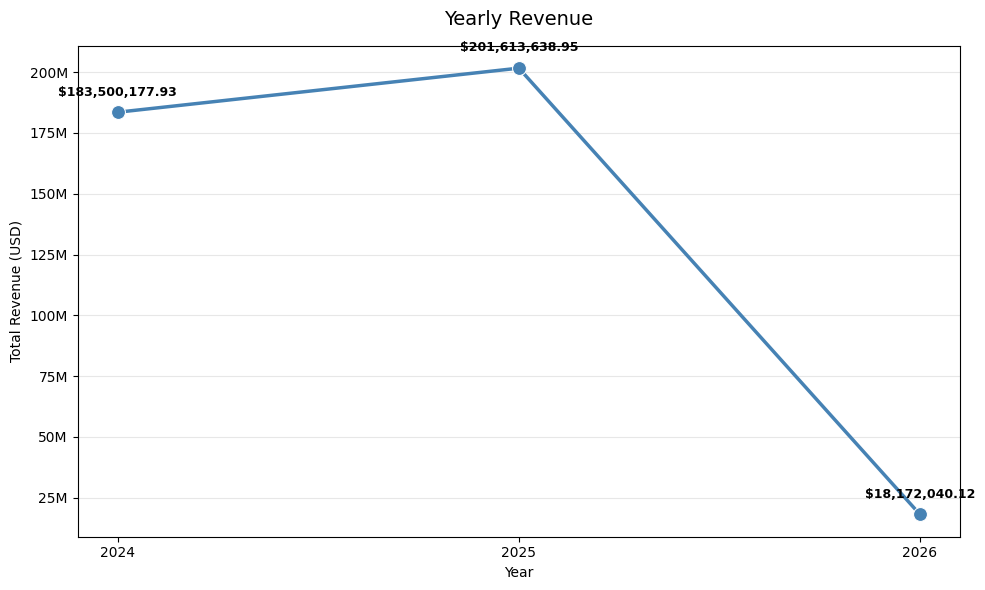

In [12]:
yearly_revenue = (
    sales_df.groupby('order_year')['net_revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_revenue,
    x='order_year',
    y='net_revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

# Add value labels on each marker
for x, y in zip(yearly_revenue['order_year'], yearly_revenue['net_revenue_usd']):
    ax.annotate(
        f'${y:,.2f}',              
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Yearly Revenue', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.xticks(yearly_revenue['order_year'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Revenue by Month

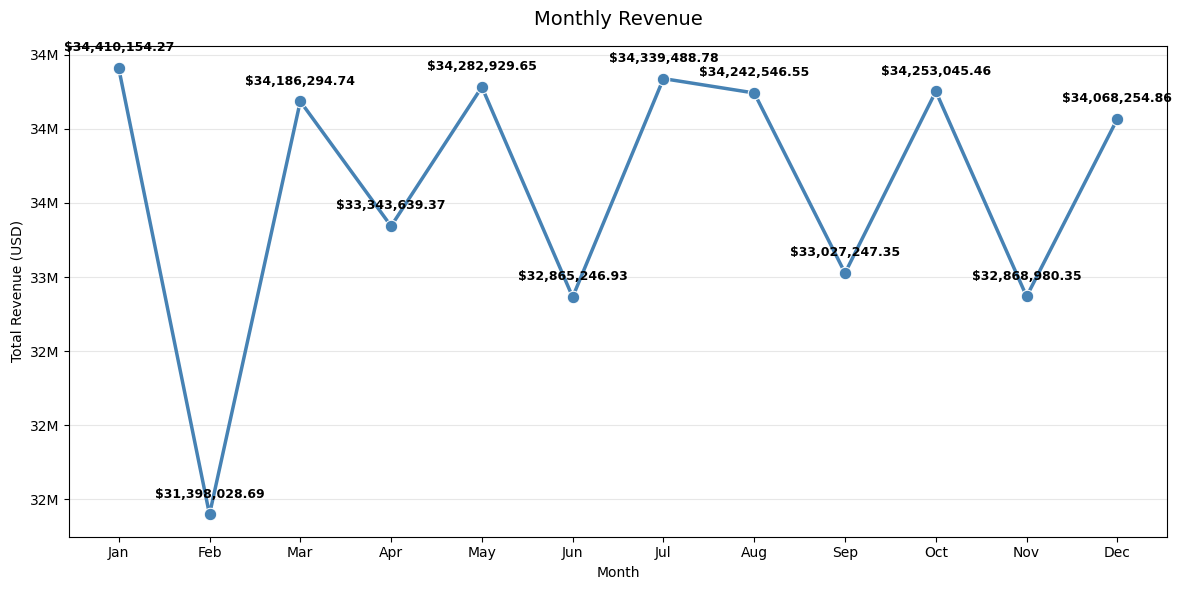

In [13]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_map = {i+1: m for i, m in enumerate(month_order)}

monthly_revenue = (
    sales_df.assign(
        order_month_name=sales_df['order_month'].map(month_map)
    )
    .groupby('order_month_name')['net_revenue_usd']
    .sum()
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_revenue,
    x='order_month_name',
    y='net_revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue'
)

for x, y in zip(monthly_revenue['order_month_name'], monthly_revenue['net_revenue_usd']):
    ax.annotate(
        f'${y:,.2f}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Monthly Revenue', fontsize=14, pad=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.3 Revenue by Day of Week

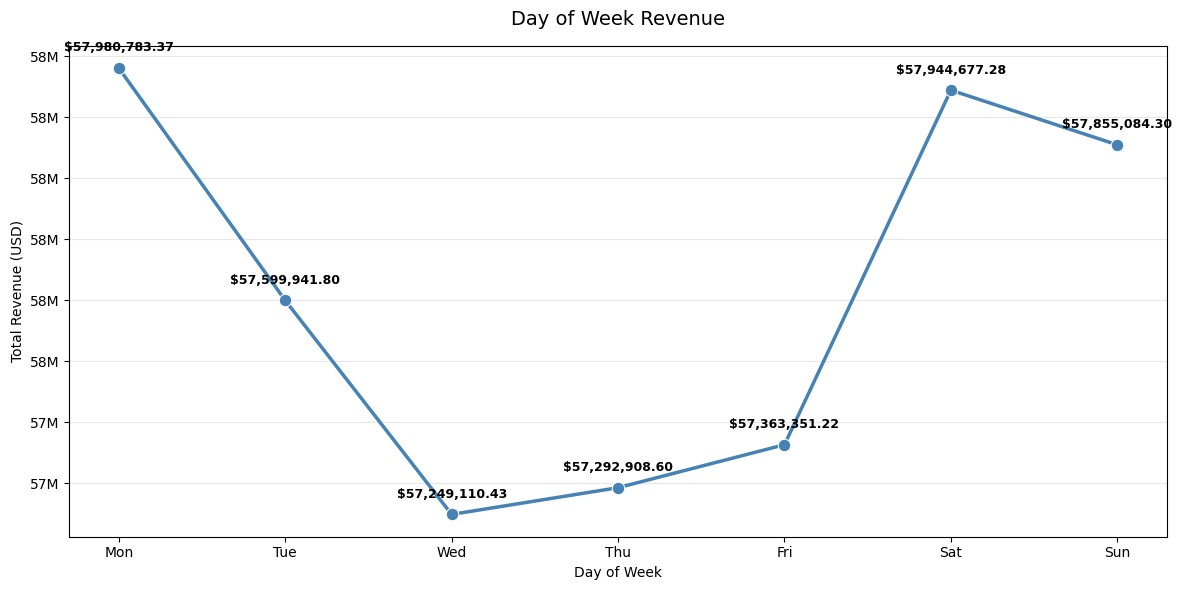

In [14]:
day_of_week_revenue = (
    sales_df.groupby('order_day_of_week')['net_revenue_usd']
    .sum()
    .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=day_of_week_revenue,
    x='order_day_of_week',
    y='net_revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue',
)

for x, y in zip(day_of_week_revenue['order_day_of_week'], day_of_week_revenue['net_revenue_usd']):
    ax.annotate(
        f'${y:,.2f}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Day of Week Revenue', fontsize=14, pad=15)
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.4 Revenue by Part of Day

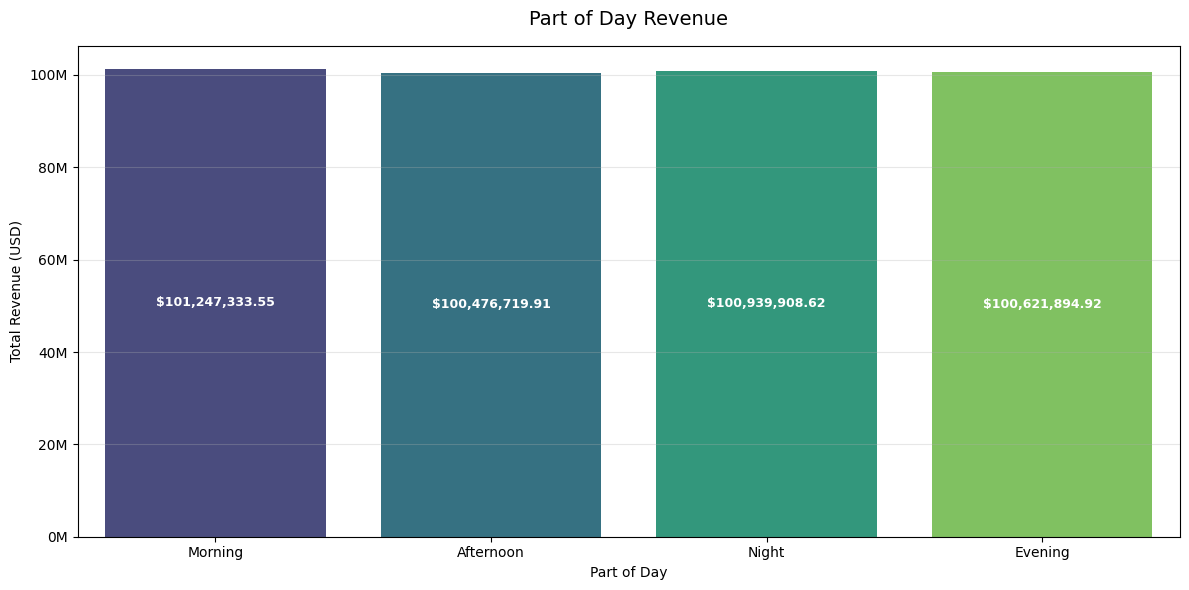

In [15]:

part_day_revenue = (
    sales_df.groupby('part_day')['net_revenue_usd']
    .sum()
    .reindex(['Morning', 'Afternoon', 'Night', 'Evening'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=part_day_revenue,
    x='part_day',
    y='net_revenue_usd',
    palette='viridis',
    hue='part_day',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Part of Day Revenue', fontsize=14, pad=15)
plt.xlabel('Part of Day')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.5 Revenue: Weekdays vs Weekends

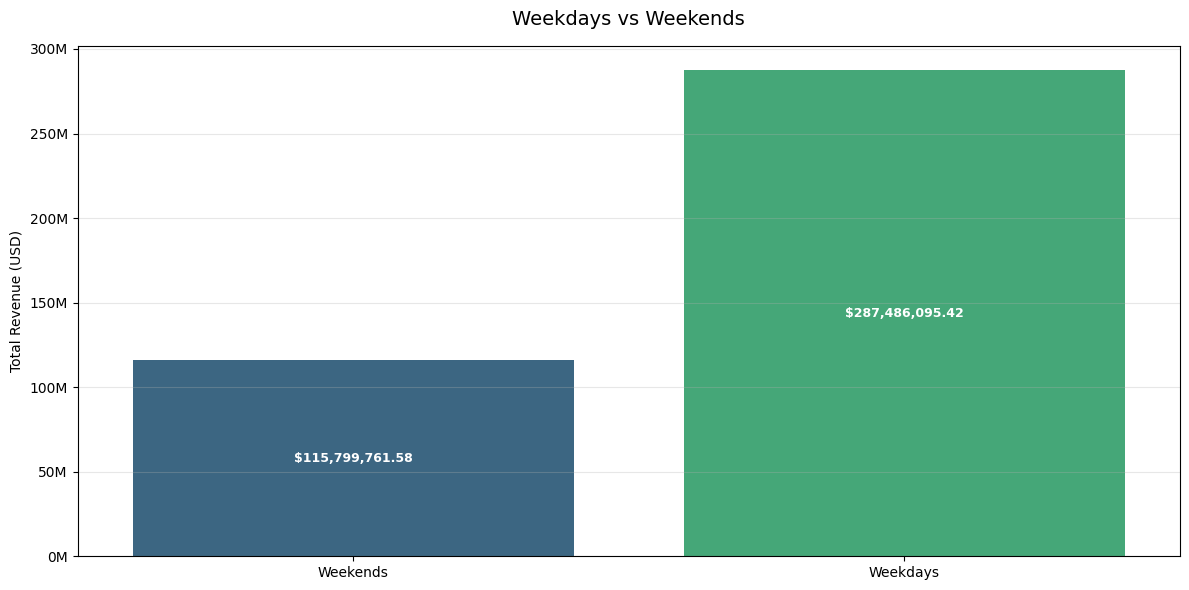

In [16]:
is_weekend_revenue = (
    sales_df.groupby('is_weekend')['net_revenue_usd']
    .sum()
    .reindex(['Yes', 'No'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=is_weekend_revenue,
    x='is_weekend',
    y='net_revenue_usd',
    palette='viridis',
    hue='is_weekend',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Weekdays vs Weekends', fontsize=14, pad=15)
plt.xlabel('')
plt.xticks([0, 1], ['Weekends', 'Weekdays'])
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Product Sales Performance

### 2.1 Revenue by Category

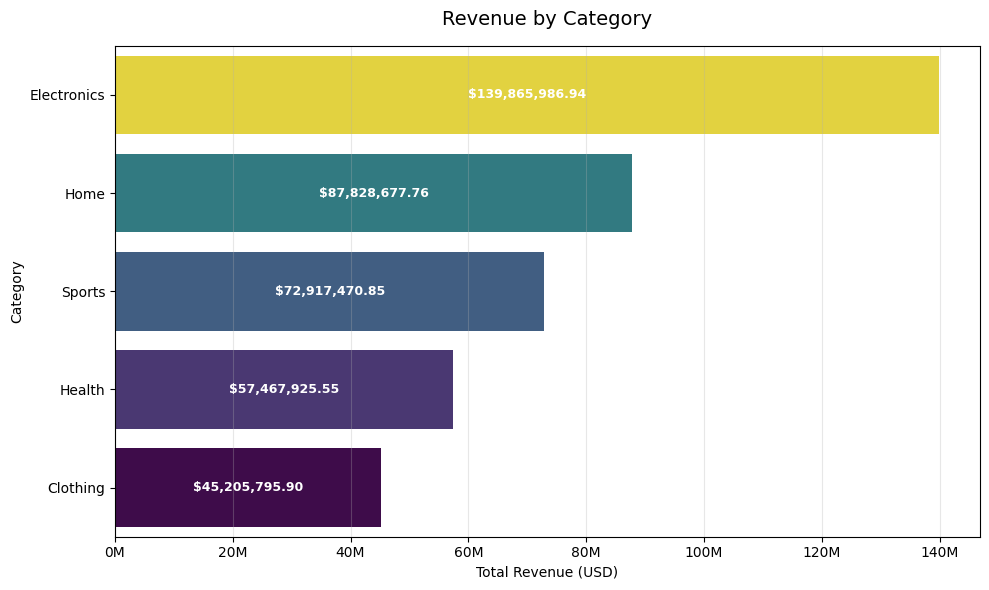

In [17]:

category_revenue = (
    sales_df.groupby('category')['net_revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_revenue,
    x='net_revenue_usd',
    y='category',
    palette='viridis',
    orient='h',
    hue='net_revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Revenue by Category', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Top 10 Revenue Sub-Categories

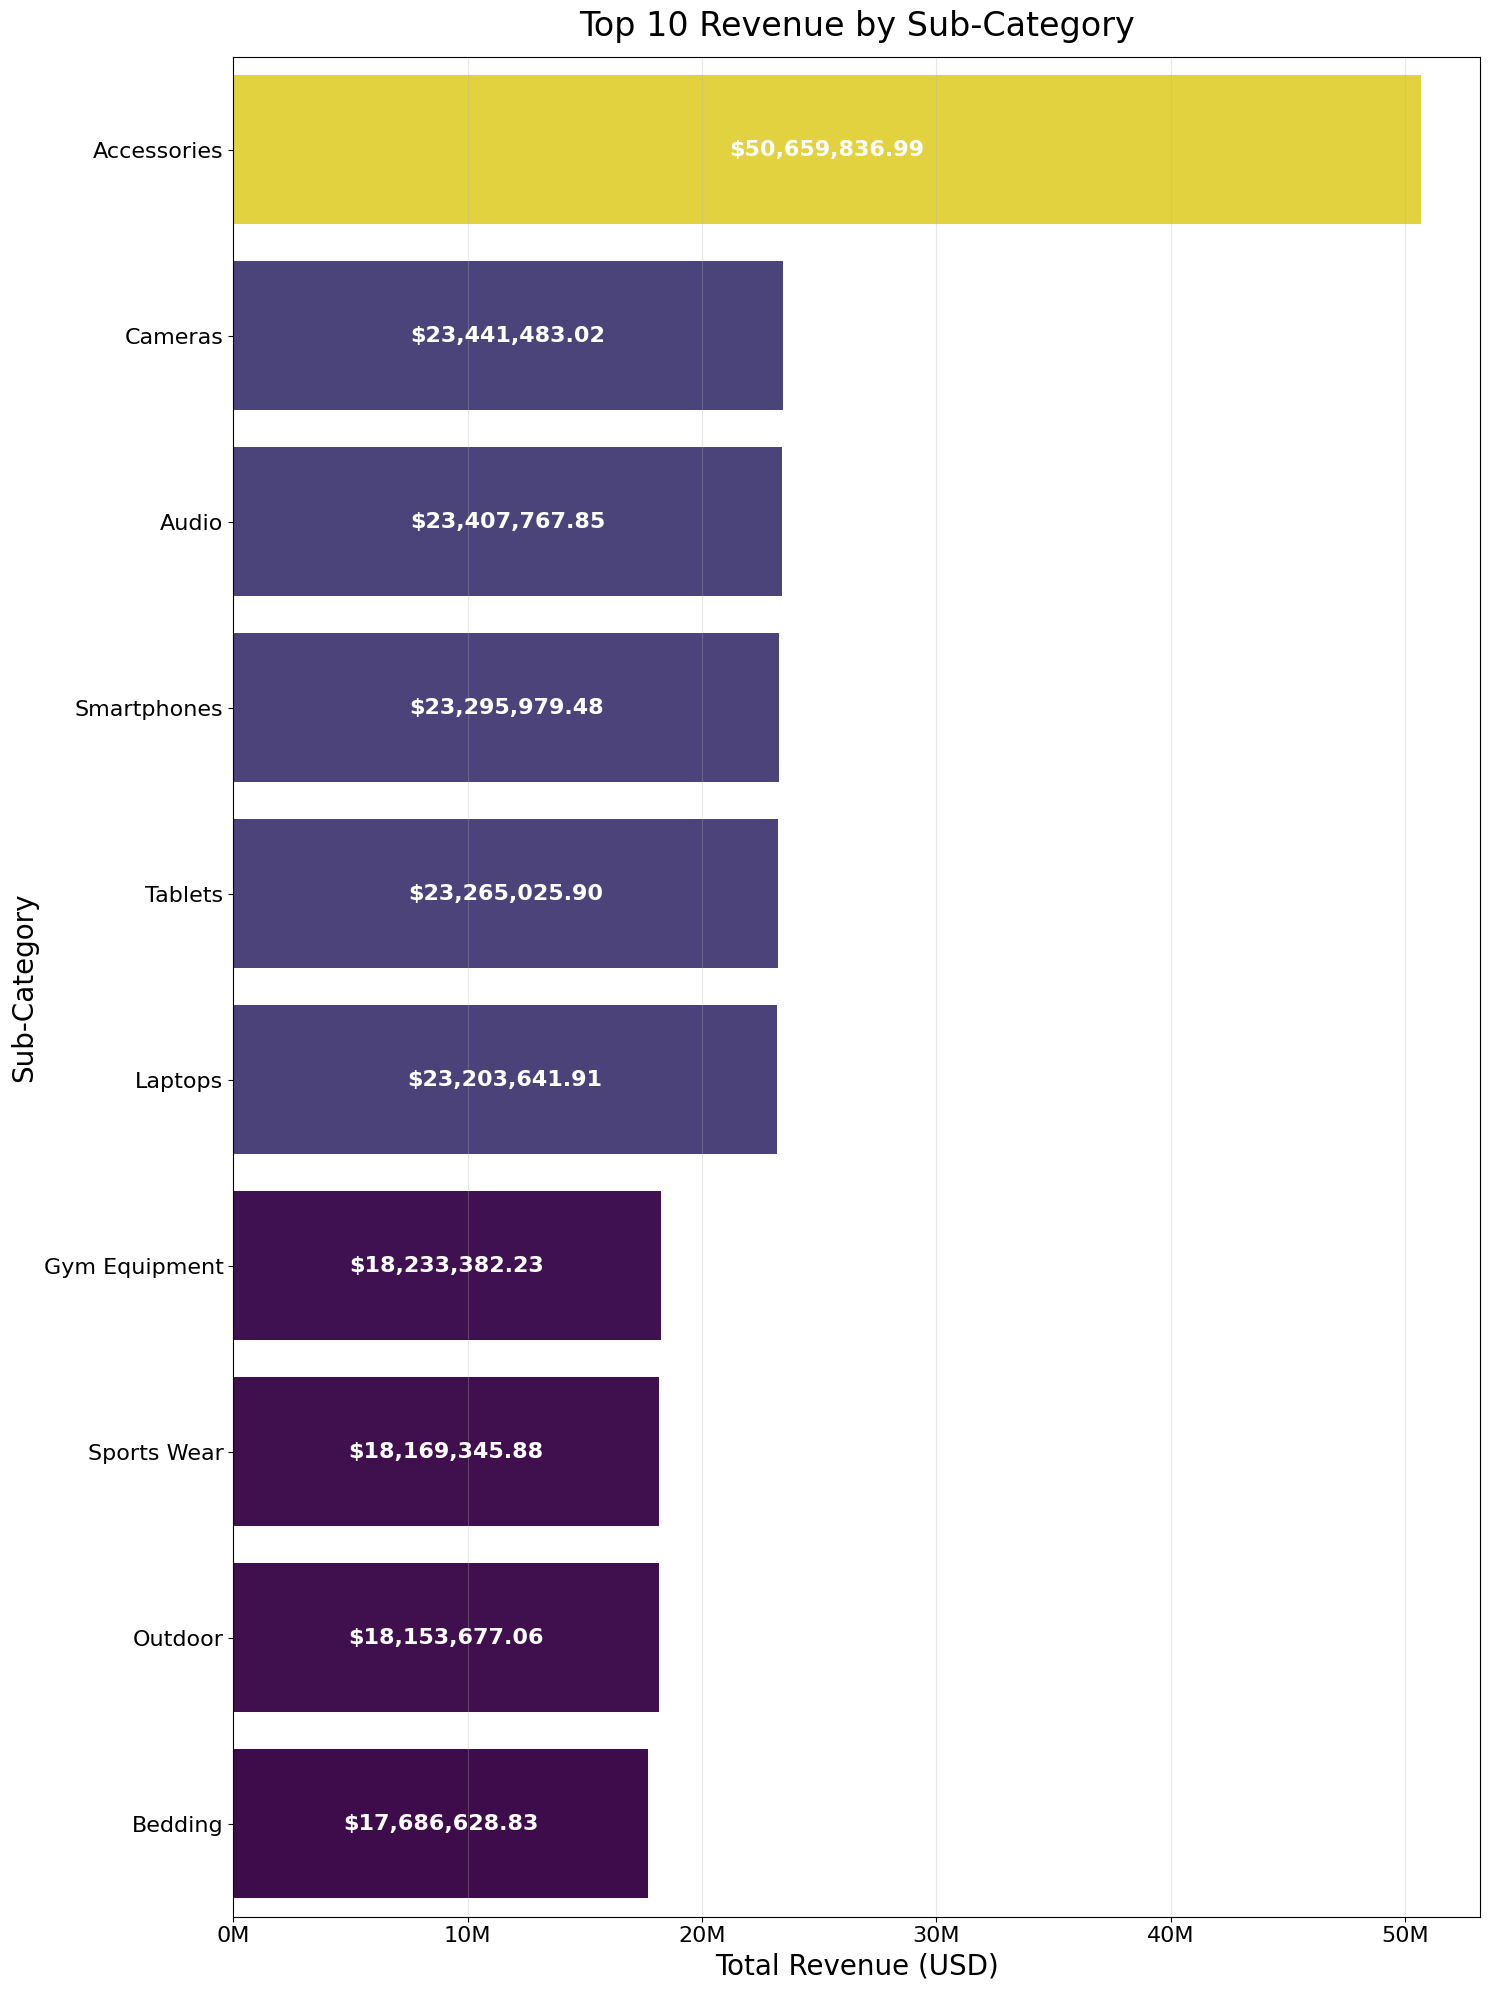

In [18]:
subcategory_revenue = (
    sales_df.groupby('sub_category')['net_revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(15, 20))

ax = sns.barplot(
    data=subcategory_revenue,
    x='net_revenue_usd',
    y='sub_category',
    palette='viridis',
    orient='h',
    hue='net_revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=16,
        fontweight='bold'
    )
    

plt.title('Top 10 Revenue by Sub-Category', fontsize=24, pad=15)
plt.xlabel('Total Revenue (USD)', fontsize=20)
plt.ylabel('Sub-Category', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3 Average Unit Price by Category and Price Tier

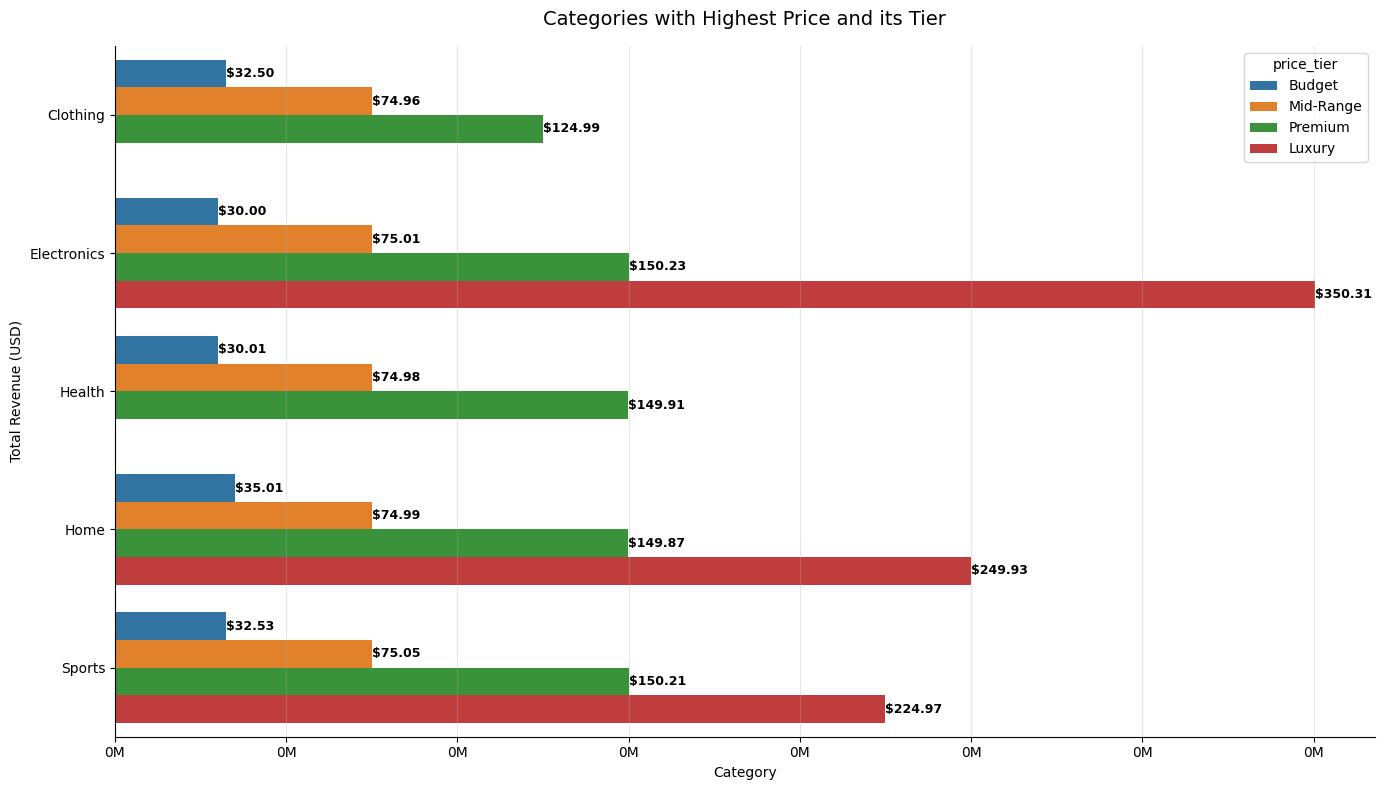

In [19]:
price_category = (
    sales_df
    .groupby(['category', 'price_tier'])['unit_price_usd']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=price_category,
    x='unit_price_usd',
    y='category',
    hue='price_tier',
    palette='tab10',
    orient='h'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Categories with Highest Price and its Tier', fontsize=14, pad=15)
plt.xlabel('Category')
plt.ylabel('Total Revenue (USD)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.4 Total Quantity Sold by Category

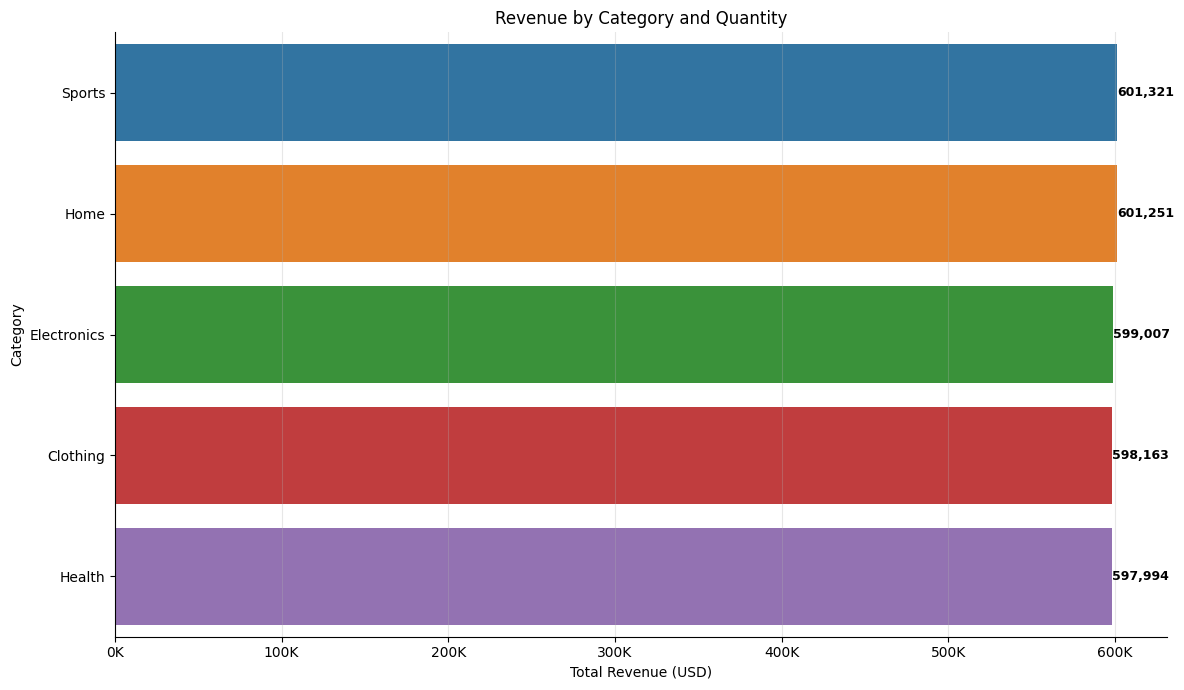

In [20]:
quantity_category = (
    sales_df
    .groupby('category')['quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=quantity_category,
    x='quantity',
    y='category',
    palette='tab10',
    hue='category',
    legend=False,
    orient='h',
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.0f}' for v in container.datavalues],
        label_type='edge',
        color='black',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Revenue by Category and Quantity')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Geographic Sales Performance

### 3.1 Revenue by Country

C:\Users\User\AppData\Local\Temp\ipykernel_6032\2291804543.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


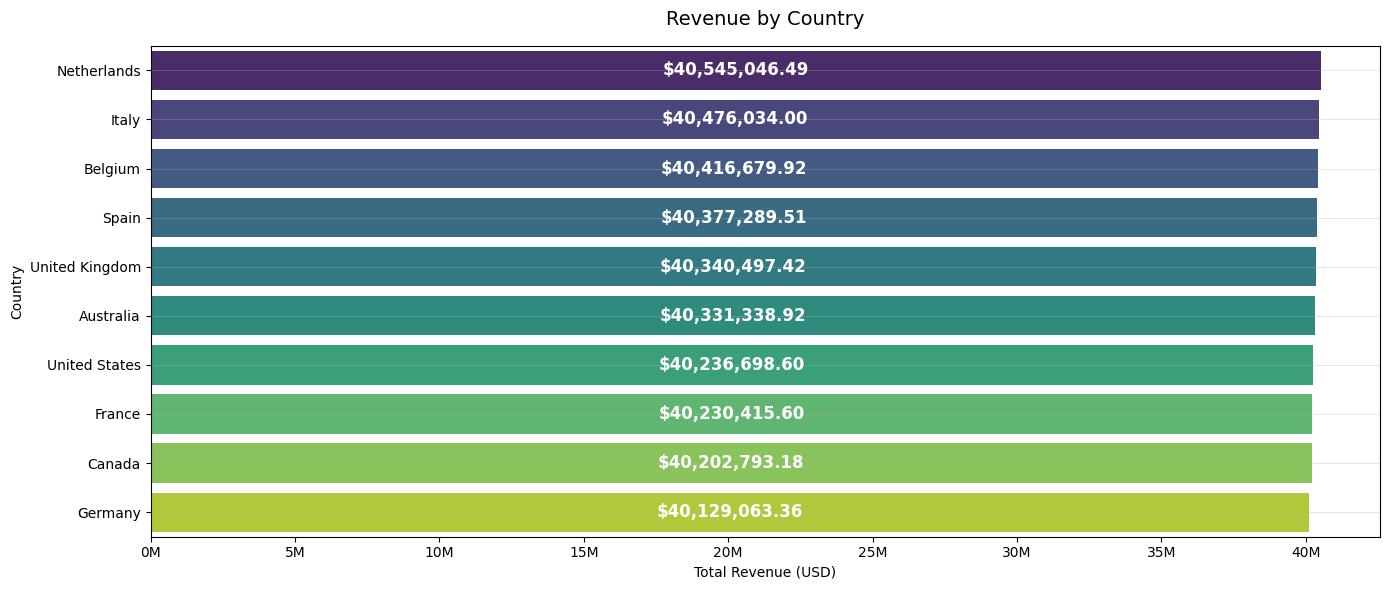

In [21]:
country_revenue = (
    sales_df.groupby('country')['net_revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=country_revenue,
    x='net_revenue_usd',
    y='country',
    orient='h',
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold',
    )

plt.title('Revenue by Country', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Country')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Revenue by Country Across Years

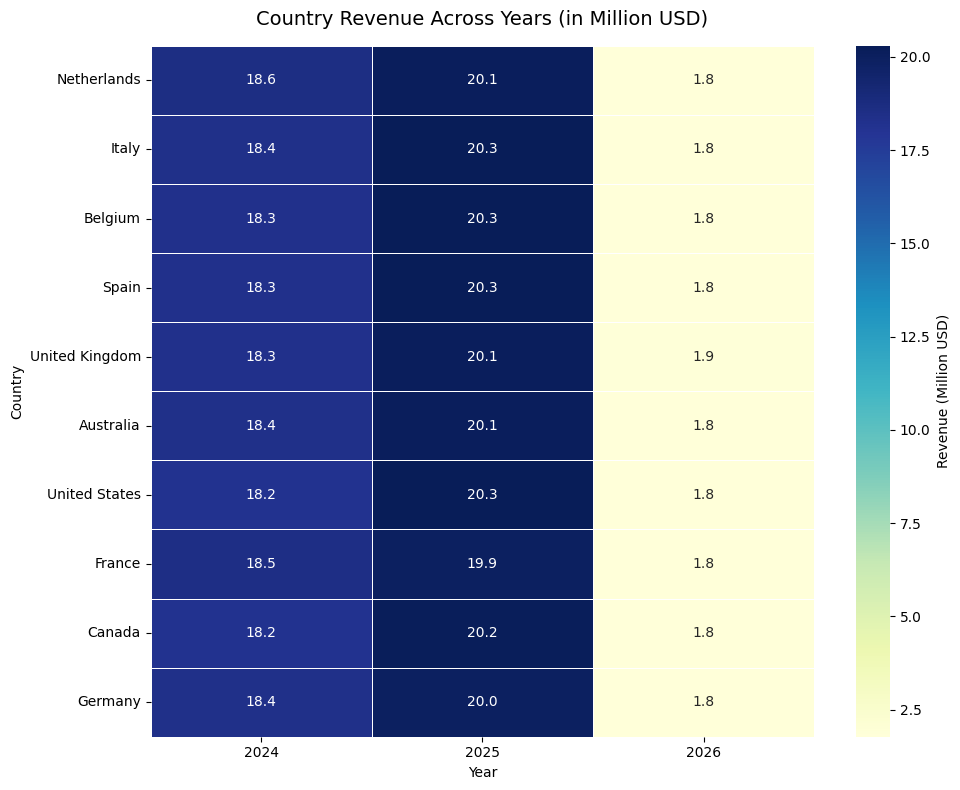

In [22]:
# Prepare data
country_yearly = (
    sales_df.groupby(['country', 'order_year'])['net_revenue_usd']
    .sum()
    .unstack(fill_value=0)          # years become columns
)

# Optional: sort by total revenue
country_yearly = country_yearly.loc[
    country_yearly.sum(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    country_yearly / 1e6,           # show in millions
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Revenue (Million USD)'}
)

plt.title('Country Revenue Across Years (in Million USD)', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

## 4. Order Value Analysis

### 4.1 Revenue by Order Value Segment

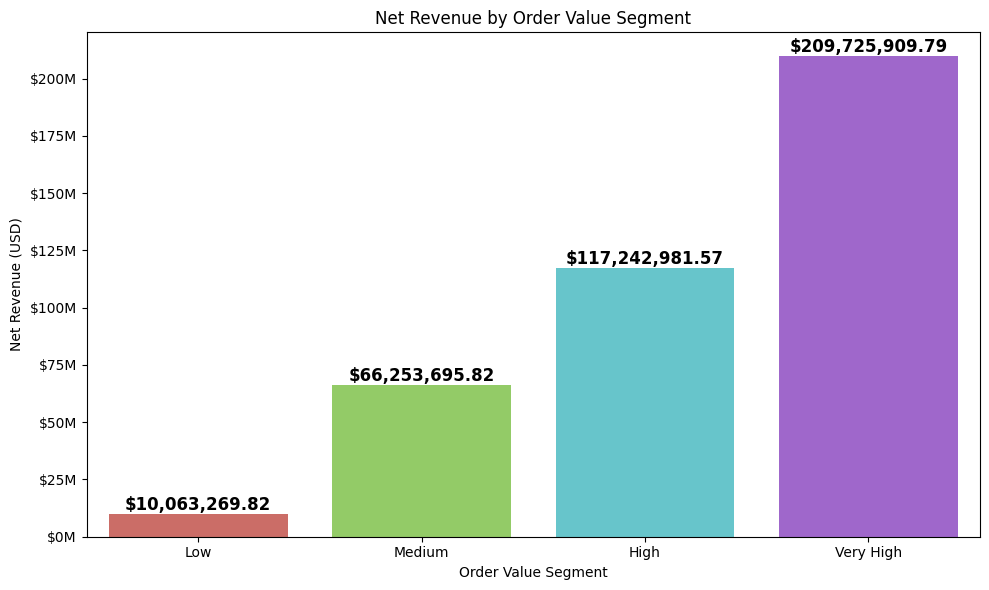

In [23]:
order_value_revenue = (
    sales_df
    .groupby('order_value_segment')['net_revenue_usd']
    .sum()
    .reset_index()
)

order_value_revenue['order_value_segment'] = pd.Categorical(
    order_value_revenue['order_value_segment'],
    categories=['Low', 'Medium', 'High', 'Very High'],
    ordered=True
)

order_value_revenue = order_value_revenue.sort_values('order_value_segment')

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=order_value_revenue,
    x='order_value_segment',
    y='net_revenue_usd',
    palette=sns.color_palette('hls',4),
    hue='order_value_segment',
    legend=False
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )

plt.title('Net Revenue by Order Value Segment')
plt.xlabel('Order Value Segment')
plt.ylabel('Net Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

### 4.2 Order Value Segment Across Categories

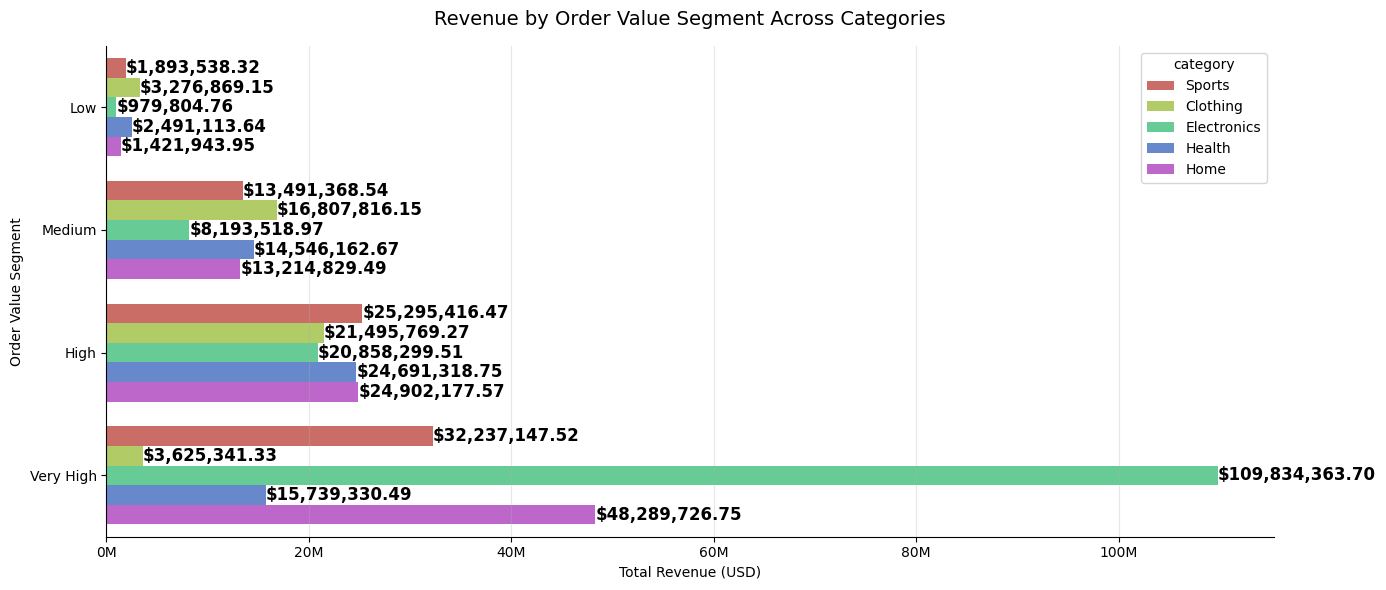

In [24]:
order_value_segment_revenue = (
    sales_df
    .groupby(['order_value_segment', 'category'])['net_revenue_usd']
    .sum()
    .reset_index()
)

order_value_segment_revenue['order_value_segment'] = pd.Categorical(
    order_value_segment_revenue['order_value_segment'],
    categories=['Low', 'Medium', 'High', 'Very High'],
    ordered=True
)

order_value_segment_revenue = order_value_segment_revenue.sort_values('order_value_segment')

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=order_value_segment_revenue,
    x='net_revenue_usd',
    y='order_value_segment',
    hue='category',
    palette=sns.color_palette('hls',5),
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Revenue by Order Value Segment Across Categories', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel("Order Value Segment")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Sales Analysis by Customer Attributes

### 5.1 Revenue Contribution by Customer Segment (%)

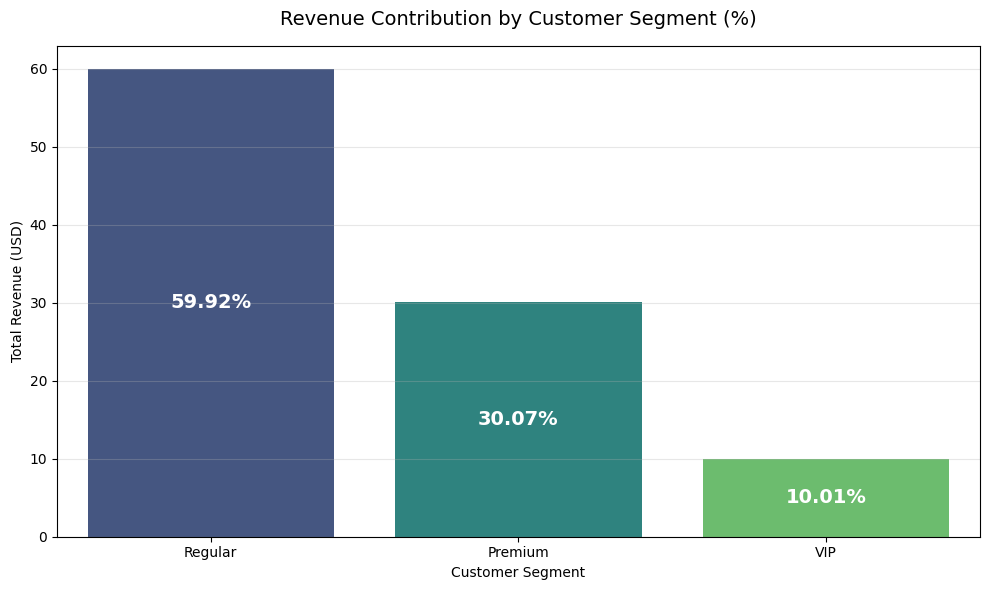

In [31]:
customer_segment_revenue = sales_df.groupby('customer_segment')['net_revenue_usd'].sum().reset_index().sort_values('net_revenue_usd', ascending=False).head(15)

total_revenue = customer_segment_revenue['net_revenue_usd'].sum()
customer_segment_revenue['revenue_pct'] = (customer_segment_revenue['net_revenue_usd'] / total_revenue) * 100

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=customer_segment_revenue,
    x='customer_segment',
    y='revenue_pct',
    hue='customer_segment',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=14,
        fontweight='bold'
    )
    
plt.title('Revenue Contribution by Customer Segment (%)', fontsize=14, pad=15)
plt.xlabel('Customer Segment')
plt.ylabel("Revenue Contribution (%)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Revenue Contribution by Age Group (%)

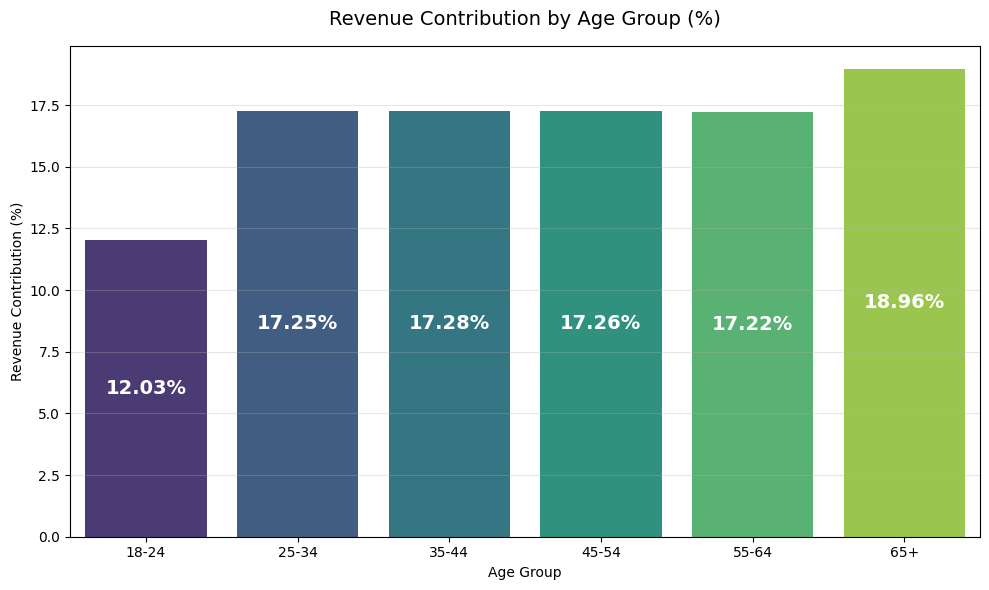

In [35]:
age_group_revenue = (
    sales_df
    .groupby('age_group')['net_revenue_usd']
    .sum()
    .reindex(['18-24', '25-34', '35-44', '45-54', '55-64', '65+'])
    .reset_index()
    .head(15)
)

total_revenue = age_group_revenue['net_revenue_usd'].sum()
age_group_revenue['revenue_pct'] = (age_group_revenue['net_revenue_usd'] / total_revenue) * 100

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=age_group_revenue,
    x='age_group',
    y='revenue_pct',
    hue='age_group',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=14,
        fontweight='bold'
    )
    
plt.title('Revenue Contribution by Age Group (%)', fontsize=14, pad=15)
plt.xlabel('Age Group')
plt.ylabel("Revenue Contribution (%)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Revenue Contribution by Gender (%)

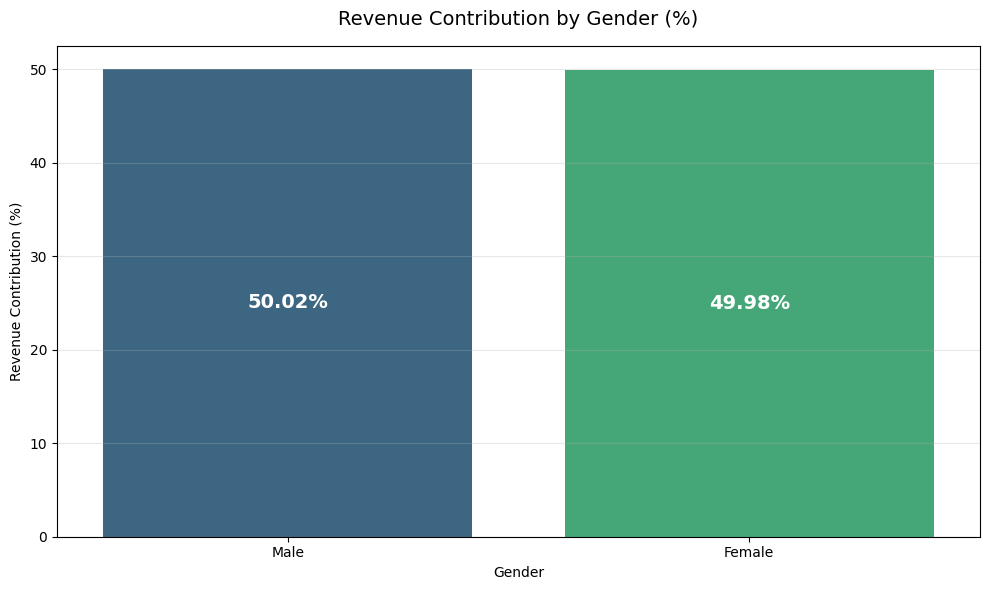

In [37]:
gender_revenue = (
    sales_df
    .groupby('gender')['net_revenue_usd']
    .sum()
    .reindex(['Male', 'Female'])
    .reset_index()
    .head(15)
)

total_revenue = gender_revenue['net_revenue_usd'].sum()
gender_revenue['revenue_pct'] = (gender_revenue['net_revenue_usd'] / total_revenue) * 100

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=gender_revenue,
    x='gender',
    y='revenue_pct',
    hue='gender',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=14,
        fontweight='bold'
    )
    
plt.title('Revenue Contribution by Gender (%)', fontsize=14, pad=15)
plt.xlabel('Gender')
plt.ylabel("Revenue Contribution (%)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Average Order Value by Customer Segment

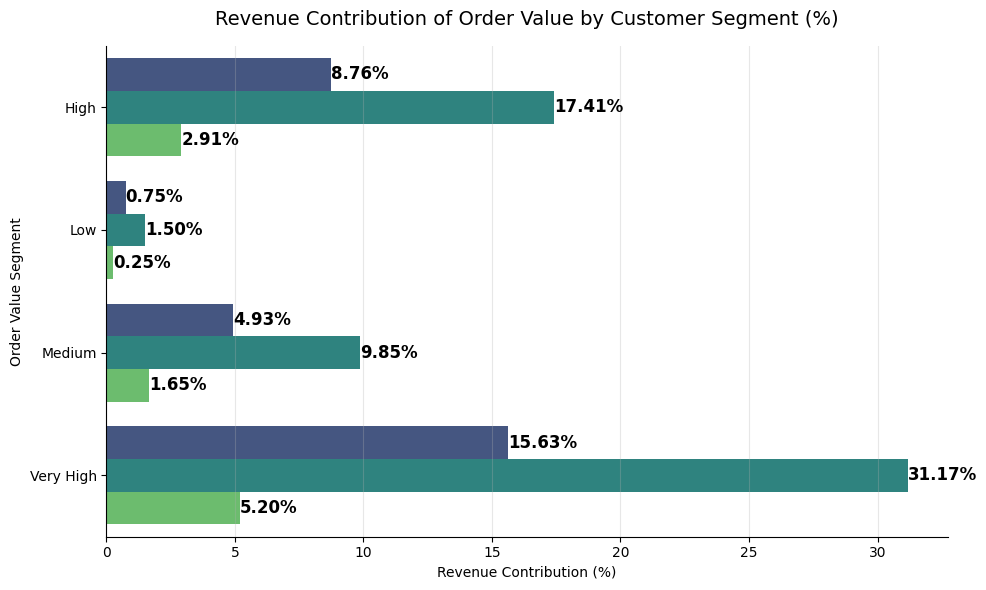

In [51]:
order_value_by_customer_segment = (
    sales_df
    .groupby(['customer_segment', 'order_value_segment'])['net_revenue_usd']
    .sum()
    .reset_index()
)

total_revenue = order_value_by_customer_segment['net_revenue_usd'].sum()
order_value_by_customer_segment['revenue_pct'] = (order_value_by_customer_segment['net_revenue_usd'] / total_revenue) * 100

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=order_value_by_customer_segment,
    x='revenue_pct',
    y='order_value_segment',
    hue='customer_segment',
    legend=False,
    palette='viridis',
    orient='h'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Revenue Contribution of Order Value by Customer Segment (%)', fontsize=14, pad=15)
plt.xlabel('Revenue Contribution (%)')
plt.ylabel("Order Value Segment")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Profitability Analysis

### 6.1 Profit by Category

### 6.2 Profit Margin by Category

### 6.3 Profit by Country

### 6.4 Revenue vs Profit by Category

## 7. Discount Analysis

### 7.1 Gross vs Net Revenue

### 7.2 Discount Impact by Year

### 7.3 Discounted vs Non-Discounted Transactions

### 7.4 Discounted vs Non-Discounted Profitability

## 1.5 Customers

In [25]:
# 1.5.1 Top 15 Customers with Highest Revenue and their Customer Segment


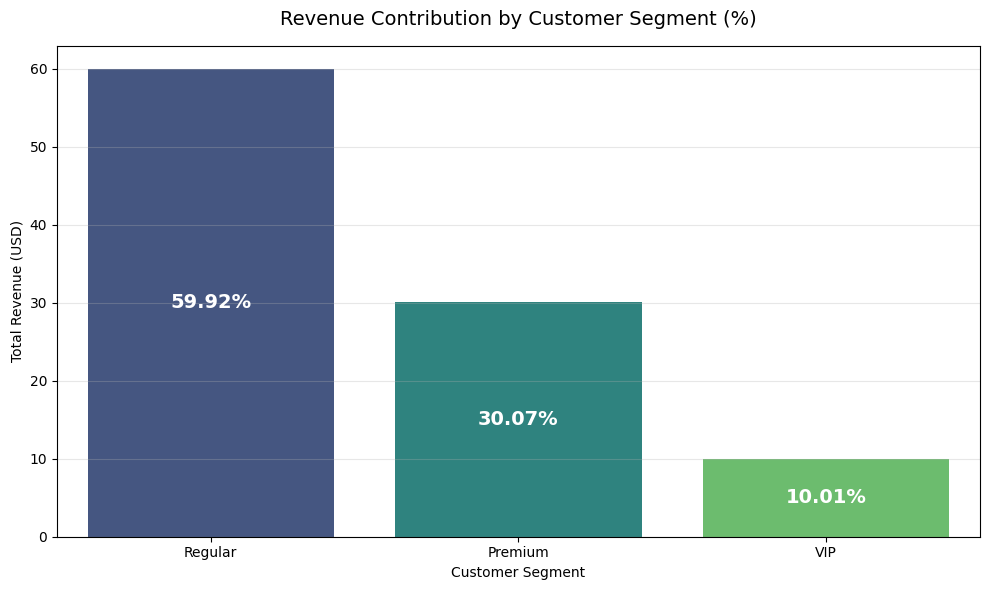

In [26]:
# 1.5.2 Customer Segment Revenue



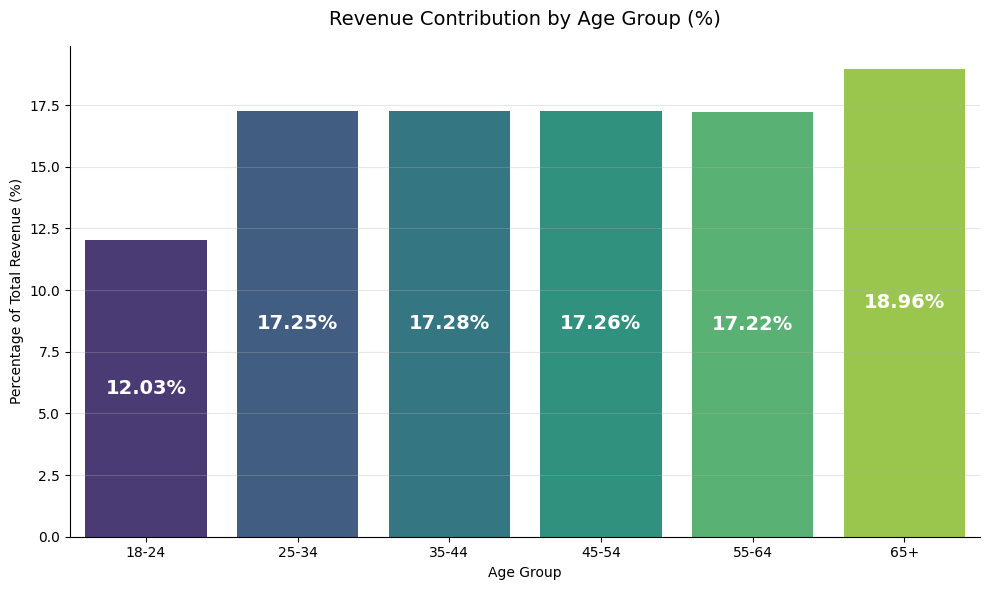

In [ ]:
# 1.5.3 Age Group Revenue 

age_group_revenue = (
    sales_df.groupby('age_group')['net_revenue_usd']
    .sum()
    .reindex(['18-24', '25-34', '35-44', '45-54', '55-64', '65+'])
    .reset_index()
)

total_revenue = age_group_revenue['net_revenue_usd'].sum()
age_group_revenue['revenue_pct'] = (age_group_revenue['net_revenue_usd'] / total_revenue) * 100

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=age_group_revenue,
    x='age_group',
    y='revenue_pct',
    palette='viridis',
    hue='age_group',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=14,
        fontweight='bold'
    )

plt.title('Revenue Contribution by Age Group (%)', fontsize=14, pad=15)
plt.xlabel('Age Group')
plt.ylabel('Percentage of Total Revenue (%)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.6 Gross Revenue (Without discount) vs Revenue (With discount applied)

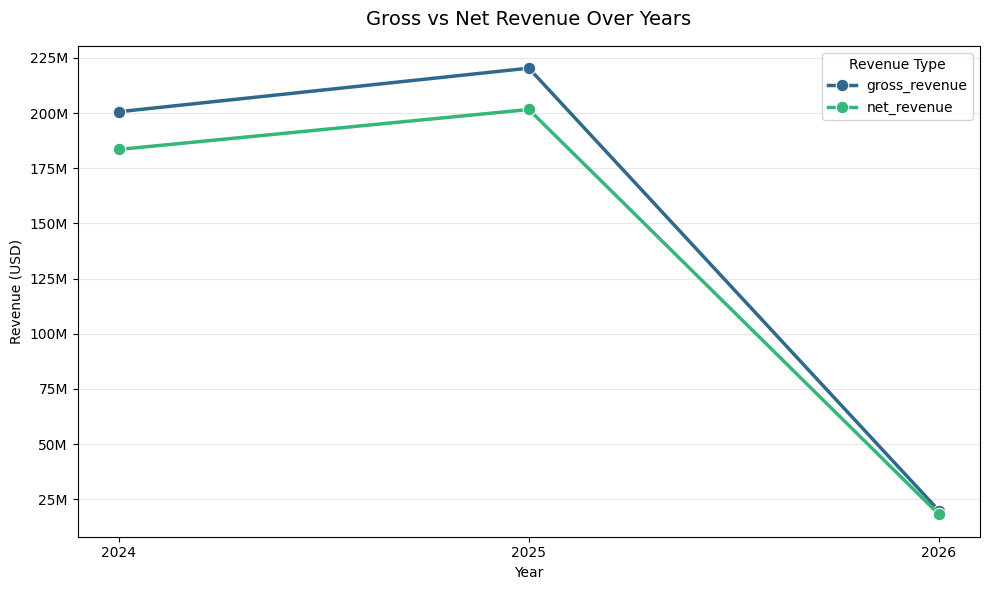

In [ ]:
# 1.6.1 Gross Revenue vs Net Revenue (Overall Discount Impact)

yearly = sales_df.groupby('order_year').agg(
    gross_revenue=('gross_revenue_usd', 'sum'),
    net_revenue=('net_revenue_usd', 'sum')
).reset_index()

# Reshape for seaborn
yearly_melted = yearly.melt(
    id_vars='order_year',
    value_vars=['gross_revenue', 'net_revenue'],
    var_name='revenue_type',
    value_name='revenue'
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_melted,
    x='order_year',
    y='revenue',
    hue='revenue_type',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='viridis'
)

plt.title('Gross vs Net Revenue Over Years', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Revenue (USD)')
plt.xticks(yearly['order_year'])
plt.legend(title='Revenue Type')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

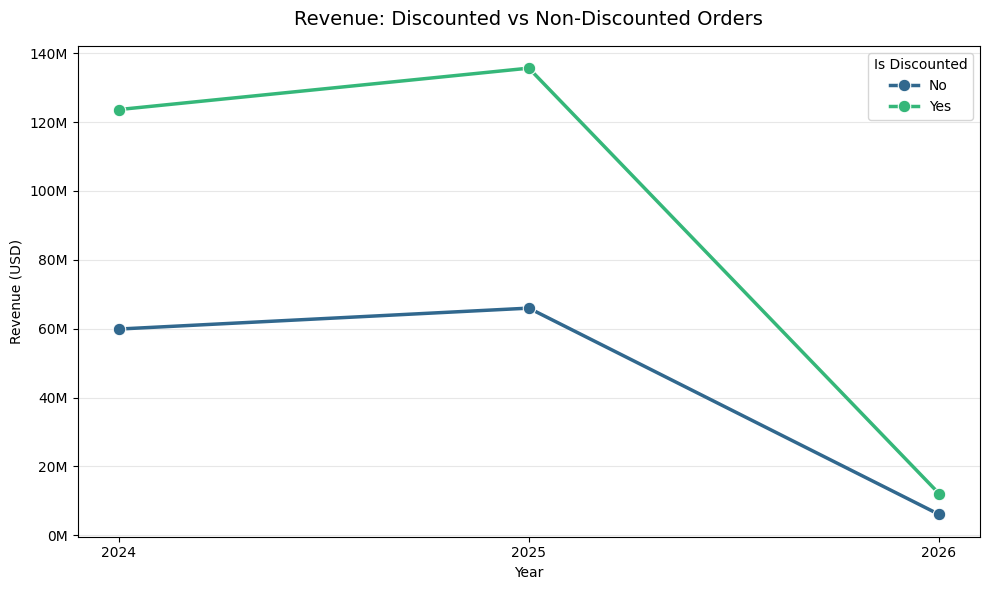

In [29]:
# 1.6.2 Discounted vs Non-Discounted Orders Revenue

discount_rev = (
    sales_df.groupby(['order_year', 'is_discounted'])['net_revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=discount_rev,
    x='order_year',
    y='net_revenue_usd',
    hue='is_discounted',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='viridis'
)

plt.title('Revenue: Discounted vs Non-Discounted Orders', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Revenue (USD)')
plt.xticks([2024, 2025, 2026])
plt.legend(title='Is Discounted')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()